In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
df = pd.read_csv("../archive/data.csv")

In [5]:
df = df.drop(columns=["id", "Unnamed: 32"])

In [6]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

In [7]:
df = df.sample(frac=1, random_state=42)

df = df.reset_index(drop=True)

In [8]:
train_ratio = 0.8

train_size = int(train_ratio * len(df))

train_df = df[:train_size]

test_df = df[train_size:]

In [9]:
X_train = train_df.drop(columns=["diagnosis"])

y_train = train_df["diagnosis"]

X_test = test_df.drop(columns=["diagnosis"])

y_test = test_df["diagnosis"]

In [10]:
X_train = X_train.to_numpy()

y_train = y_train.to_numpy()

X_test = X_test.to_numpy()

y_test = y_test.to_numpy()

In [11]:
print(X_train.shape)

print(y_train.shape)

print(X_test.shape)

print(y_test.shape)

(455, 30)
(455,)
(114, 30)
(114,)


In [12]:
train_mean = np.mean(X_train, axis=0)

In [13]:
train_std = np.std(X_train, axis=0)

In [14]:
X_train = (X_train - train_mean) / train_std

X_test = (X_test - train_mean) / train_std

In [15]:
print(X_train[:2])

[[-0.4551289  -0.1697973  -0.43324119 -0.48731502  0.23933659  0.02078204
  -0.11012954 -0.26742609  0.39844062  0.10687585 -0.0118858  -0.33492569
  -0.18933453 -0.24380276 -0.02244844 -0.36550056 -0.16355071 -0.21119796
  -0.33604478 -0.07973479 -0.25680217 -0.18410224 -0.3245997  -0.35158765
   0.45887988 -0.11073112 -0.02766304 -0.18554442  0.1644574   0.19152275]
 [ 1.40479714  0.47708079  1.33651393  1.42442348 -0.44696612 -0.03357904
   0.23753775  0.79498502 -0.82006219 -1.18810478  1.60941135 -0.77213111
   1.51557836  1.60803155 -0.8506494  -0.51245051 -0.29846809  0.33338346
  -0.81174835 -0.78584134  1.80163238  0.14136751  1.75922866  1.79000799
  -0.57457541 -0.13788476 -0.02003538  0.99265484 -0.57236563 -1.0165972 ]]


In [16]:
n_features = X_train.shape[1]

weights = np.zeros(n_features)

bias = 0

In [17]:
def sigmoid(z):

    return 1 / (1 + np.exp(-z))

In [18]:
learning_rate = 0.01

epochs = 100

loss_history = []

In [19]:
start_time = time.time()

In [22]:
%%time
for epoch in range(epochs):

    z = np.dot(X_train, weights) + bias

    predictions = sigmoid(z)

    epsilon = 1e-15

    predictions = np.clip(
        predictions,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_train * np.log(predictions)
        +
        (1 - y_train)
        *
        np.log(1 - predictions)
    )

    loss_history.append(loss)

    error = predictions - y_train

    dw = np.dot(X_train.T, error) / len(X_train)

    db = np.mean(error)

    weights = weights - learning_rate * dw

    bias = bias - learning_rate * db

    print(
        "Epoch:",
        epoch + 1,
        "Loss:",
        loss
    )

Epoch: 1 Loss: 0.2424448797846135
Epoch: 2 Loss: 0.24140346710245475
Epoch: 3 Loss: 0.24037608569757196
Epoch: 4 Loss: 0.23936242614904285
Epoch: 5 Loss: 0.2383621884972729
Epoch: 6 Loss: 0.23737508187802675
Epoch: 7 Loss: 0.23640082417343264
Epoch: 8 Loss: 0.23543914167904725
Epoch: 9 Loss: 0.2344897687861213
Epoch: 10 Loss: 0.2335524476782621
Epoch: 11 Loss: 0.2326269280417344
Epoch: 12 Loss: 0.2317129667886867
Epoch: 13 Loss: 0.23081032779263527
Epoch: 14 Loss: 0.2299187816355739
Epoch: 15 Loss: 0.22903810536611577
Epoch: 16 Loss: 0.22816808226810945
Epoch: 17 Loss: 0.22730850163920055
Epoch: 18 Loss: 0.22645915857884372
Epoch: 19 Loss: 0.22561985378529514
Epoch: 20 Loss: 0.2247903933611444
Epoch: 21 Loss: 0.22397058862696717
Epoch: 22 Loss: 0.22316025594270547
Epoch: 23 Loss: 0.22235921653640275
Epoch: 24 Loss: 0.22156729633994093
Epoch: 25 Loss: 0.220784325831448
Epoch: 26 Loss: 0.2200101398840595
Epoch: 27 Loss: 0.21924457762073798
Epoch: 28 Loss: 0.21848748227486586
Epoch: 29 Lo

In [23]:
z_test = np.dot(X_test, weights) + bias

test_probabilities = sigmoid(z_test)

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

In [24]:
accuracy = np.mean(
    test_predictions == y_test
)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


In [25]:
accuracy = np.mean(
    test_predictions == y_test
)

In [26]:
TP = np.sum(
    (y_test == 1)
    &
    (test_predictions == 1)
)

TN = np.sum(
    (y_test == 0)
    &
    (test_predictions == 0)
)

FP = np.sum(
    (y_test == 0)
    &
    (test_predictions == 1)
)

FN = np.sum(
    (y_test == 1)
    &
    (test_predictions == 0)
)

In [28]:
print("True Positives :", TP)

print("True Negatives :", TN)

print("False Positives:", FP)

print("False Negatives:", FN)

True Positives : 43
True Negatives : 65
False Positives: 2
False Negatives: 4


In [29]:
precision = TP / (TP + FP)

print("Precision:", precision)

Precision: 0.9555555555555556


In [30]:
recall = TP / (TP + FN)

print("Recall:", recall)

Recall: 0.9148936170212766


In [31]:
f1_score = (
    2 * precision * recall
    /
    (precision + recall)
)

print("F1 Score:", f1_score)

F1 Score: 0.9347826086956522


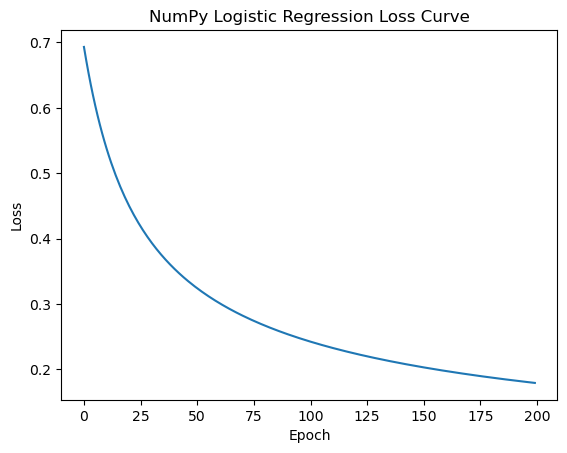

In [32]:
plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("NumPy Logistic Regression Loss Curve")

plt.show()

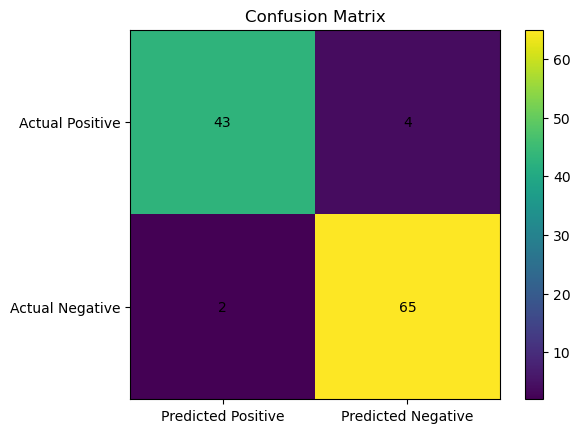

In [33]:
confusion_matrix = [
    [TP, FN],
    [FP, TN]
]

plt.imshow(confusion_matrix)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Predicted Positive", "Predicted Negative"]
)

plt.yticks(
    [0, 1],
    ["Actual Positive", "Actual Negative"]
)

plt.title("Confusion Matrix")

plt.text(0, 0, TP, ha='center', va='center')
plt.text(1, 0, FN, ha='center', va='center')
plt.text(0, 1, FP, ha='center', va='center')
plt.text(1, 1, TN, ha='center', va='center')

plt.show()